# ACE trajectories example


In [5]:
from pathlib import Path
import importlib.util


def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs
from functions.sc_pos.interactive_orbits_timeseries_plus3d import *


## Build the 3D trajectory figure


In [3]:


targets = ["ACE", "WIND", "DISCOVER", "ADITYA-L1", "IMAP", 'SOLAR-1']

fig_3d = build_3d_figure(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="6h",
    frame3d="GSE",
    rss_rsun=20,
    #skip_small_bodies=True,
)

fig_3d.show()


[3D] Building 3D figure in frame3d=GSE (positions in AU).
[3D] GSE mode: single geocentric panel with axis/sun-wind guides (no Sun backmapping inset).
INFO: Obtained JPL HORIZONS location for Earth (399) [sunpy.coordinates.ephemeris]


13-Feb-26 07:41:31: Obtained JPL HORIZONS location for Earth (399)


[3D] Adding ecliptic plane patch in target frame.
[3D] ACE -> ACE: fetching ephemeris (SPKID=-92), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]


13-Feb-26 07:41:32: Obtained JPL HORIZONS location for ACE (spacecraft) (-92)


[3D] WIND -> WIND: fetching ephemeris (SPKID=-8), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]


...

13-Feb-26 07:41:34: Obtained JPL HORIZONS location for James Webb Space Telescope (spac


[3D] IMAP -> IMAP: fetching ephemeris (SPKID=-43), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43) [sunpy.coordinates.ephemeris]


13-Feb-26 07:41:35: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43)


[3D] SOLAR-1 -> SOLAR-1: fetching ephemeris (SPKID=-231), building trajectory and footpoints...
INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]


13-Feb-26 07:41:36: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231)


##### Build synchronized longitude/latitude time series


In [ ]:
fig_ts = build_timeseries_figure(
    targets=targets,
    start="2021-10-01T00:00:00",
    stop="2021-12-10T00:00:00",
    step="6h",
    lon_unwrap_deg=False,
)

fig_ts.show()


## MRE: first-principles stream-separation metric (step by step)

This minimal reproducible example (MRE) intentionally keeps a few assumptions fixed so the method is transparent:

- **Hardcoded/assumed in this notebook run:** `flow_dir_gse=(-1,0,0)`, constant `vsw_kms=400`, `perp_scale=0.35`, `lag_tolerance=0.5`.
- **Why this is limited:** real solar wind has time-varying speed and flow direction, and anisotropy changes with conditions.
- **How to improve with real data:** replace constants by measured `Vsw(t)`, infer local flow direction from plasma moments, and make decorrelation scales time dependent.

The solver minimizes a conservative estimate of the probability that **all** selected spacecraft observe the same stream.


INFO: Obtained JPL HORIZONS location for ACE (spacecraft) (-92) [sunpy.coordinates.ephemeris]


13-Feb-26 08:01:14: Obtained JPL HORIZONS location for ACE (spacecraft) (-92)


INFO: Obtained JPL HORIZONS location for Wind (spacecraft) (-8) [sunpy.coordinates.ephemeris]


13-Feb-26 08:01:16: Obtained JPL HORIZONS location for Wind (spacecraft) (-8)


INFO: Obtained JPL HORIZONS location for DSCOVR (spacecraft) (-78) [sunpy.coordinates.ephemeris]


...

13-Feb-26 08:01:19: Obtained JPL HORIZONS location for IMAP (spacecraft) (-43)


INFO: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231) [sunpy.coordinates.ephemeris]


13-Feb-26 08:01:21: Obtained JPL HORIZONS location for SWFO-L1 (spacecraft) (-231)


[alignment] Stream-separation model (GSE):
  - Uses |d_parallel| for lags (fixes signed-max bug).
  - L_adv=0.1733 AU (4063.9 Re), L_perp=0.0606 AU (1422.4 Re), tau0=9.00 h.


,window_start,window_end,n_samples,coverage,alignment_metric,alignment_metric_p16,alignment_metric_p84,same_stream_prob,same_stream_prob_p16,same_stream_prob_p84,same_flow_score,same_flow_score_p16,same_flow_score_p84,median_perp_au,median_par_au,median_tau_h,max_perp_au,max_par_au,max_tau_h
0,2025-11-15 17:59:59.999667385,2025-11-16 11:59:59.999667385,6,1.0,0.981752,0.966217,0.989014,0.979722,0.964164,0.986993,0.020278,0.020269,0.020285,0.004627,0.000404,0.041963,0.008661,0.000808,0.083926
1,2025-11-14 23:59:59.999667385,2025-11-15 17:59:59.999667385,6,1.0,0.981754,0.966262,0.988997,0.979762,0.964230,0.987021,0.020238,0.020222,0.020251,0.004638,0.000374,0.038854,0.008655,0.000748,0.077708
2,2025-11-14 05:59:59.999667385,2025-11-14 23:59:59.999667385,6,1.0,0.981770,0.966338,0.988987,0.979826,0.964337,0.987065,0.020174,0.020152,0.020195,0.004635,0.000345,0.035836,0.008644,0.000689,0.071583


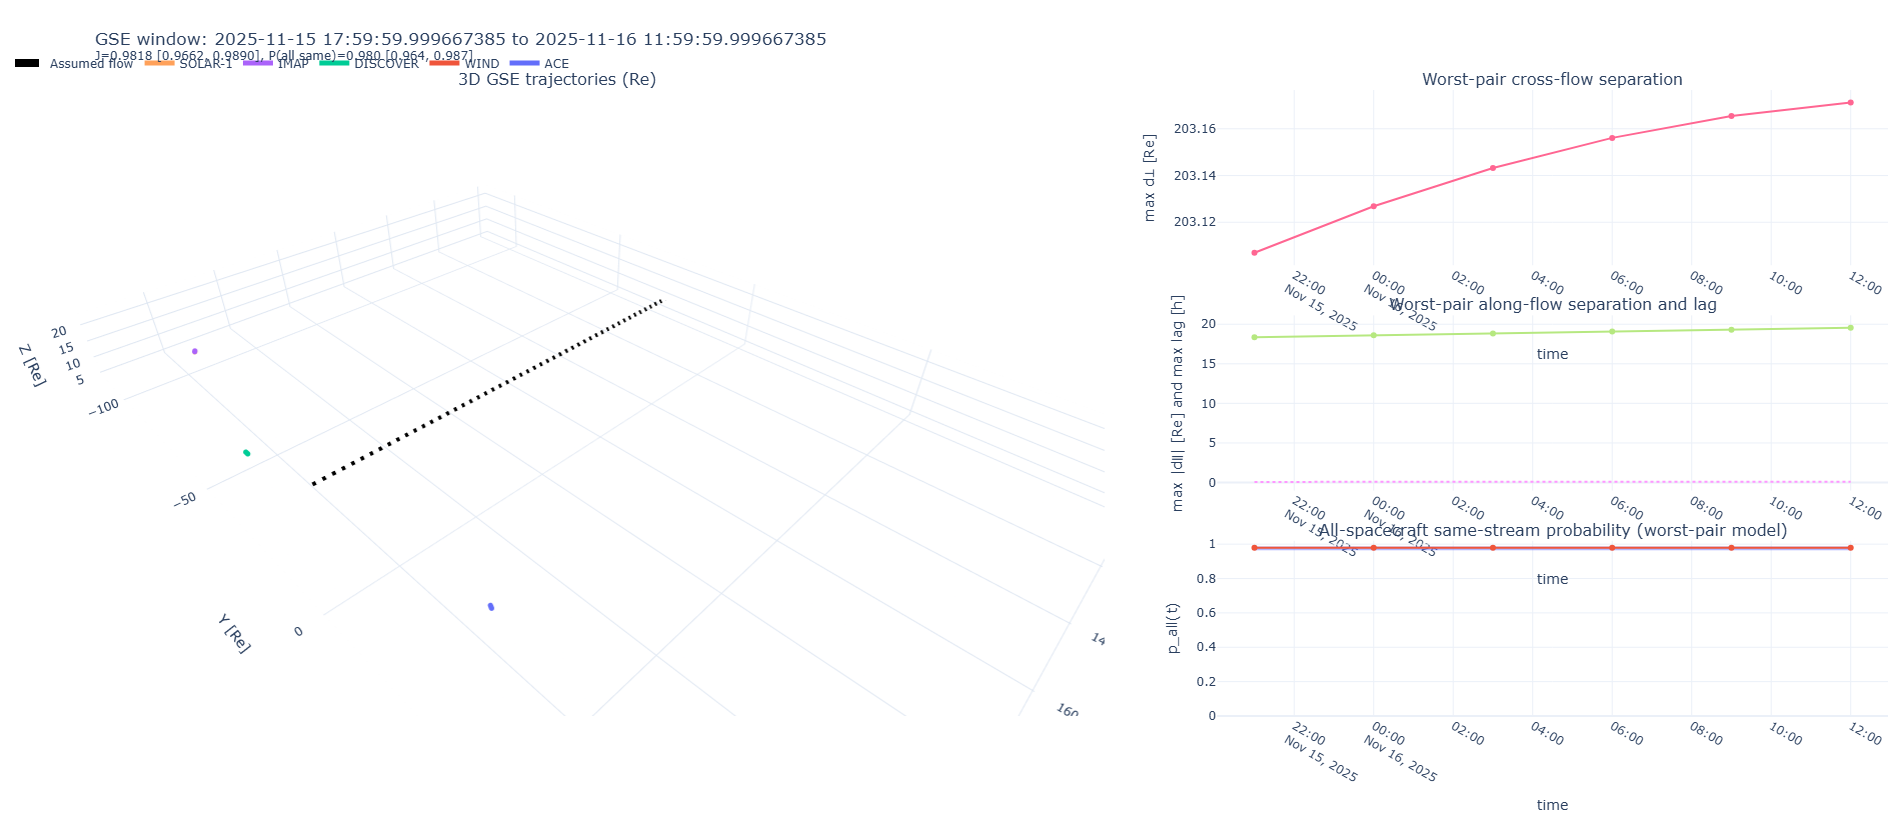

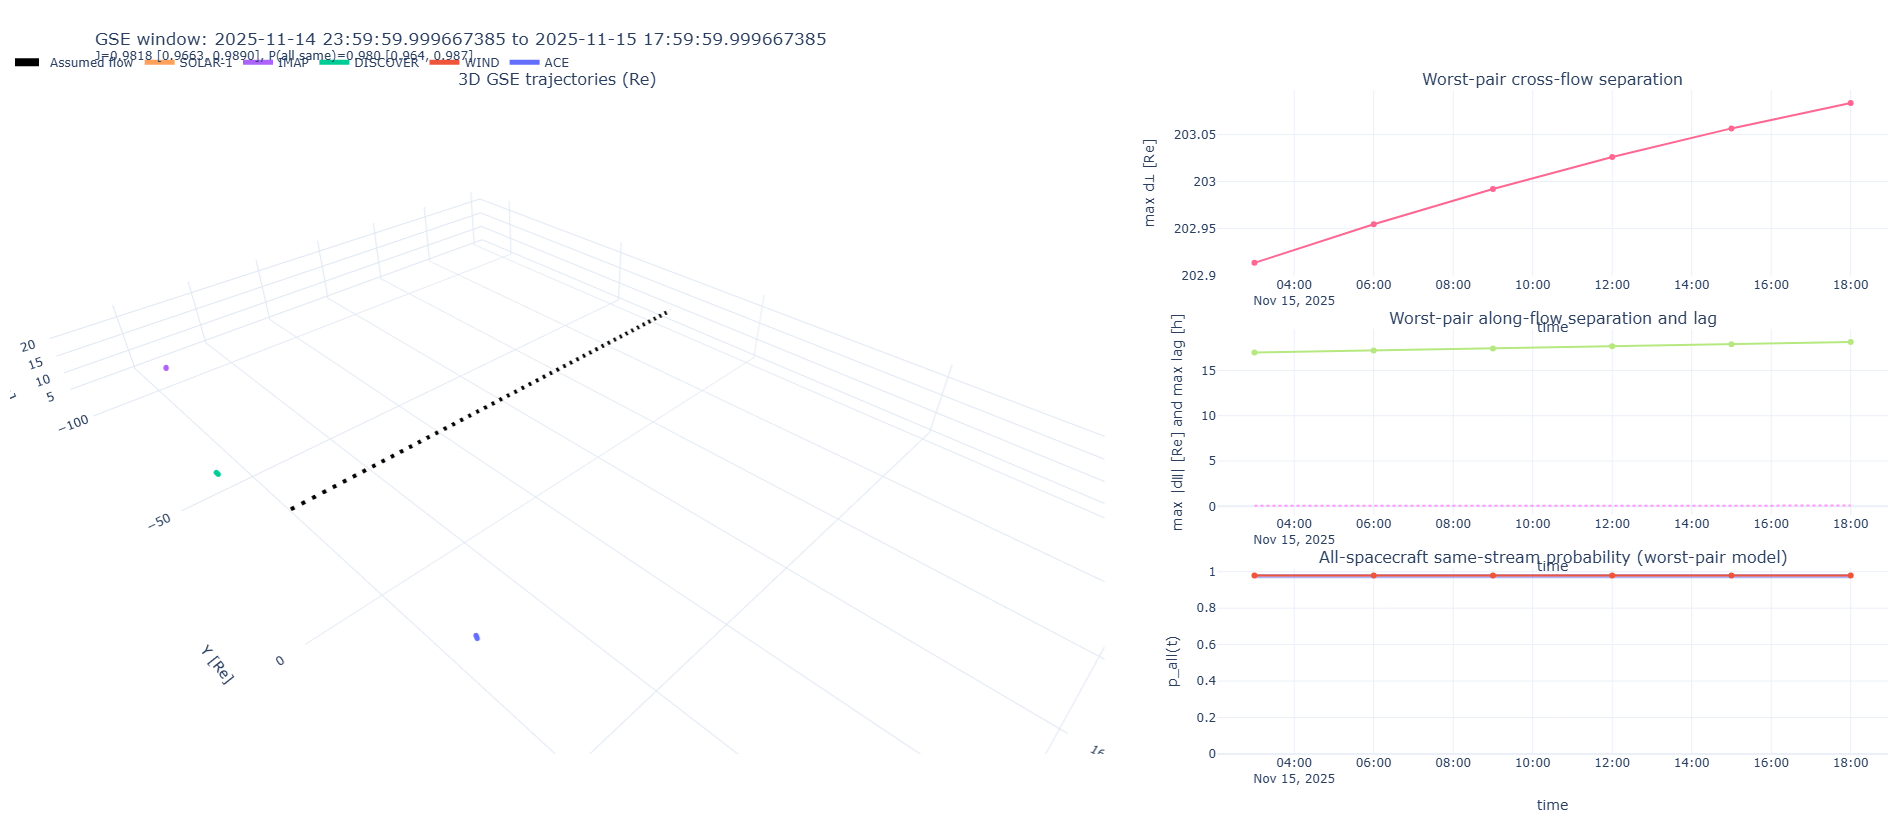

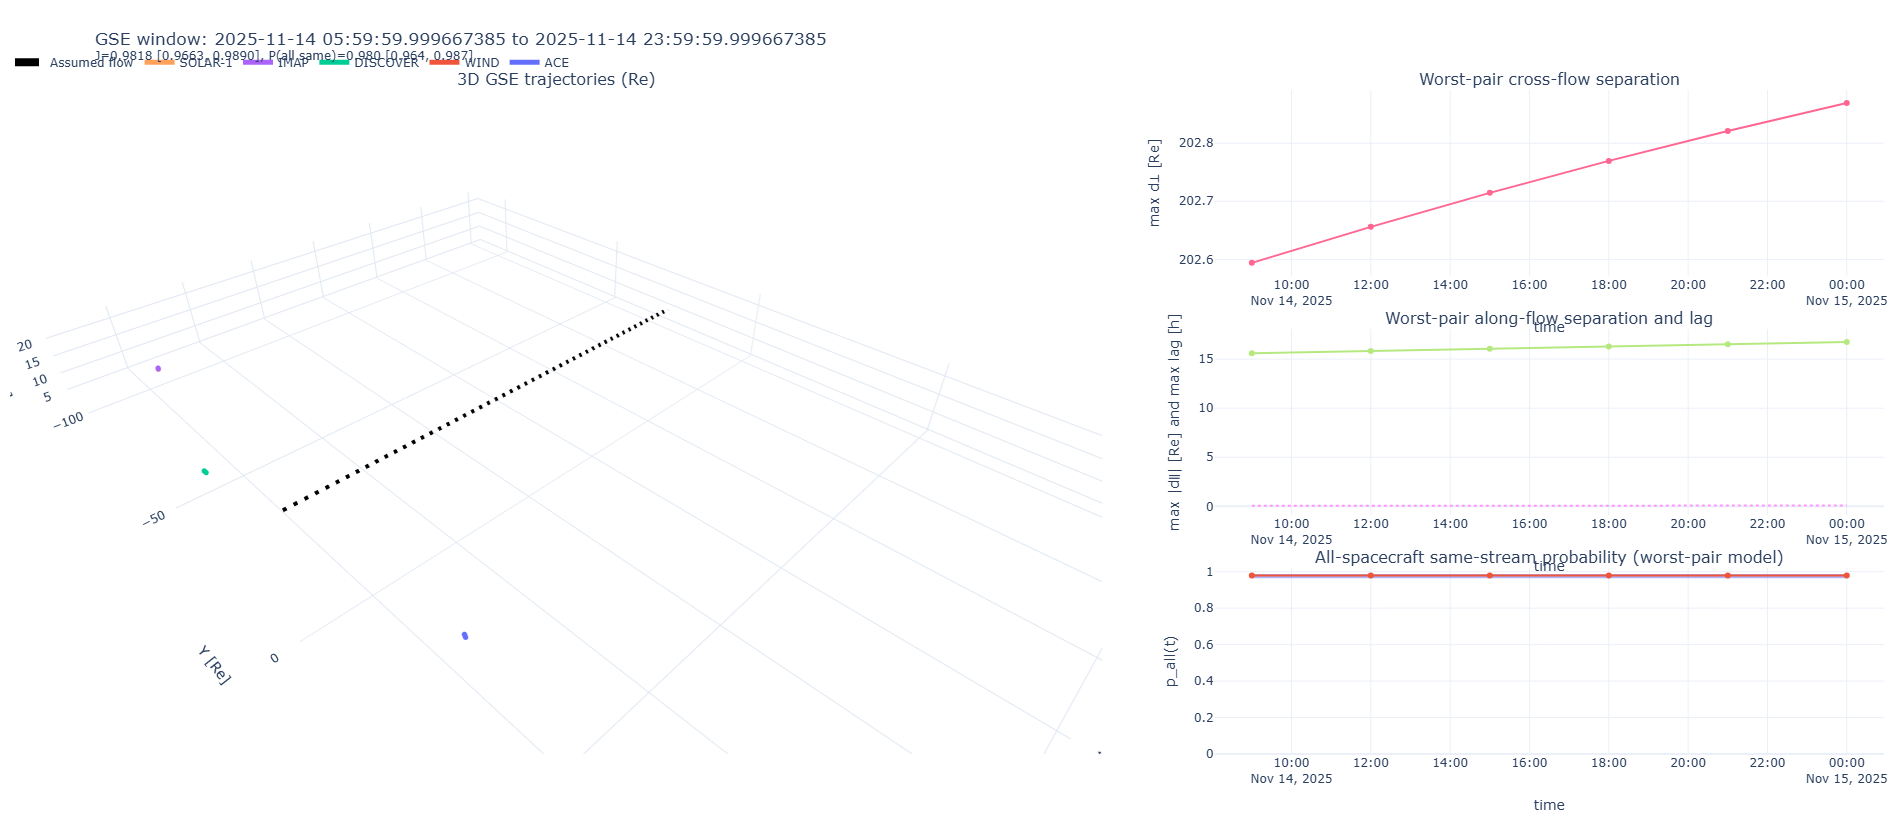

In [7]:
import pandas as pd


targets = ["ACE", "WIND", "DISCOVER",  "IMAP", "SOLAR-1"]

metric_cfg = dict(
    targets=targets,
    start="2025-10-01T00:00:00",
    stop="2025-12-10T00:00:00",
    step="3h",
    window_hours=18.0,
    top_n=3,
    frame="GSE",
    flow_dir_gse=(-1.0, 0.0, 0.0),
    vsw_kms=400.0,
    perp_scale=0.35,
    lag_tolerance=0.5,
    along_weight=0.25,
    vsw_rel_unc=0.15,
    decorrelation_rel_unc=0.25,
    min_coverage=0.8,
    verbose=True,
)

scores_out = find_best_stream_aligned_intervals(**metric_cfg)

best_windows = scores_out["best"]
cols = [
    "window_start",
    "window_end",
    "n_samples",
    "coverage",
    "alignment_metric",
    "alignment_metric_p16",
    "alignment_metric_p84",
    "same_stream_prob",
    "same_stream_prob_p16",
    "same_stream_prob_p84",
    "same_flow_score",
    "same_flow_score_p16",
    "same_flow_score_p84",
    "median_perp_au",
    "median_par_au",
    "median_tau_h",
    "max_perp_au",
    "max_par_au",
    "max_tau_h",
]
display(best_windows[cols])

alignment_figs = []
for _, row in best_windows.iterrows():
    alignment_figs.append(
        plot_stream_alignment_interval(
            tracks=scores_out["tracks"],
            targets=targets,
            window_start=row["window_start"],
            window_end=row["window_end"],
            flow_hat=scores_out["flow_hat"],
            summary_row=row,
        )
    )

for fig in alignment_figs:
    fig.show()